# Titanic EDA – Exploratory Data Analysis & Business Insights

**Project 2: Exploratory Data Analysis**
**Dataset:** Cleaned Titanic Dataset (from Project 1)

This notebook analyzes the cleaned Titanic dataset to discover survival patterns, answer business questions, and generate insights and recommendations for a shipping company's management team.

### Setup: Import Libraries

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Part 1: Data Understanding

### • Loading the Dataset

In [80]:
df = pd.read_csv('Cleaned_Titanic.csv')

### • Displaying First 5 Rows

In [81]:
df.head()

,passenger_id,name,sex,age,passenger_class,ticket_number,fare,deck,has_cabin_recorded,siblings_spouses_aboard,parents_children_aboard,port_of_embarkation,survived
0,1,"Braund, Mr. Owen Harris",male,22.0,3,A/5 21171,7.25,Unknown,0,1,0,Southampton,No
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,PC 17599,71.28,C,1,1,0,Cherbourg,Yes
2,3,"Heikkinen, Miss. Laina",female,26.0,3,STON/O2. 3101282,7.92,Unknown,0,0,0,Southampton,Yes
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,113803,53.10,C,1,1,0,Southampton,Yes
4,5,"Allen, Mr. William Henry",male,35.0,3,373450,8.05,Unknown,0,0,0,Southampton,No


### • Displaying Last 5 Rows

In [82]:
df.tail()

,passenger_id,name,sex,age,passenger_class,ticket_number,fare,deck,has_cabin_recorded,siblings_spouses_aboard,parents_children_aboard,port_of_embarkation,survived
886,887,"Montvila, Rev. Juozas",male,27.0,2,211536,13.00,Unknown,0,0,0,Southampton,No
887,888,"Graham, Miss. Margaret Edith",female,19.0,1,112053,30.00,B,1,0,0,Southampton,Yes
888,889,"Johnston, Miss. Catherine Helen ""Carrie""",female,21.5,3,W./C. 6607,23.45,Unknown,0,1,2,Southampton,No
889,890,"Behr, Mr. Karl Howell",male,26.0,1,111369,30.00,C,1,0,0,Cherbourg,Yes
890,891,"Dooley, Mr. Patrick",male,32.0,3,370376,7.75,Unknown,0,0,0,Queenstown,No


### • Printing Dataset Shape

In [83]:
print(df.shape)

(891, 13)


In [84]:
##OR
print("Rows and Columns:", df.shape)

Rows and Columns: (891, 13)


In [85]:
##OR
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 891
Columns: 13


### • Displaying Column Names

In [86]:
df.columns


Index(['passenger_id', 'name', 'sex', 'age', 'passenger_class',
       'ticket_number', 'fare', 'deck', 'has_cabin_recorded',
       'siblings_spouses_aboard', 'parents_children_aboard',
       'port_of_embarkation', 'survived'],
      dtype='str')

In [87]:
##OR
df.columns.tolist()

['passenger_id',
 'name',
 'sex',
 'age',
 'passenger_class',
 'ticket_number',
 'fare',
 'deck',
 'has_cabin_recorded',
 'siblings_spouses_aboard',
 'parents_children_aboard',
 'port_of_embarkation',
 'survived']

### • Checking Data Types (info())

In [88]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   passenger_id             891 non-null    int64  
 1   name                     891 non-null    str    
 2   sex                      891 non-null    str    
 3   age                      891 non-null    float64
 4   passenger_class          891 non-null    int64  
 5   ticket_number            891 non-null    str    
 6   fare                     891 non-null    float64
 7   deck                     891 non-null    str    
 8   has_cabin_recorded       891 non-null    int64  
 9   siblings_spouses_aboard  891 non-null    int64  
 10  parents_children_aboard  891 non-null    int64  
 11  port_of_embarkation      891 non-null    str    
 12  survived                 891 non-null    str    
dtypes: float64(2), int64(5), str(6)
memory usage: 90.6 KB


### • Displaying Summary Statistics (describe())

In [89]:
df.describe() ## for numeric columns only

,passenger_id,age,passenger_class,fare,has_cabin_recorded,siblings_spouses_aboard,parents_children_aboard
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,29.112458,2.308642,32.204366,0.228956,0.523008,0.381594
std,257.353842,13.304352,0.836071,49.693414,0.420397,1.102743,0.806057
min,1.000000,0.400000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,21.500000,2.000000,7.910000,0.000000,0.000000,0.000000
50%,446.000000,26.000000,3.000000,14.450000,0.000000,0.000000,0.000000
75%,668.500000,36.000000,3.000000,31.000000,0.000000,1.000000,0.000000
max,891.000000,80.000000,3.000000,512.330000,1.000000,8.000000,6.000000


In [90]:
## OR
df.describe(include='all') ## for numeric+categorical columns

,passenger_id,name,sex,age,passenger_class,ticket_number,fare,deck,has_cabin_recorded,siblings_spouses_aboard,parents_children_aboard,port_of_embarkation,survived
count,891.000000,891,891,891.000000,891.000000,891,891.000000,891,891.000000,891.000000,891.000000,891,891
unique,NaN,891,2,NaN,NaN,681,NaN,9,NaN,NaN,NaN,3,2
top,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,347082,NaN,Unknown,NaN,NaN,NaN,Southampton,No
freq,NaN,1,577,NaN,NaN,7,NaN,687,NaN,NaN,NaN,646,549
mean,446.000000,NaN,NaN,29.112458,2.308642,NaN,32.204366,NaN,0.228956,0.523008,0.381594,NaN,NaN
std,257.353842,NaN,NaN,13.304352,0.836071,NaN,49.693414,NaN,0.420397,1.102743,0.806057,NaN,NaN
min,1.000000,NaN,NaN,0.400000,1.000000,NaN,0.000000,NaN,0.000000,0.000000,0.000000,NaN,NaN
25%,223.500000,NaN,NaN,21.500000,2.000000,NaN,7.910000,NaN,0.000000,0.000000,0.000000,NaN,NaN
50%,446.000000,NaN,NaN,26.000000,3.000000,NaN,14.450000,NaN,0.000000,0.000000,0.000000,NaN,NaN
75%,668.500000,NaN,NaN,36.000000,3.000000,NaN,31.000000,NaN,0.000000,1.000000,0.000000,NaN,NaN


### • Checking Missing Values

In [91]:
df.isnull().sum()

passenger_id               0
name                       0
sex                        0
age                        0
passenger_class            0
ticket_number              0
fare                       0
deck                       0
has_cabin_recorded         0
siblings_spouses_aboard    0
parents_children_aboard    0
port_of_embarkation        0
survived                   0
dtype: int64

### • Checking Duplicate Values

In [92]:
df.duplicated().sum()

np.int64(0)

In [93]:
#OR
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


### Dataset Description

This dataset contains passenger records from the RMS Titanic, the ship that sank in 1912 after colliding with an
iceberg. The cleaned dataset contains **891 rows and 13 columns**, each row representing one passenger. The
features include a mix of **demographic information** (age, sex), **travel details** (passenger class, fare,
ticket number, cabin deck, port of embarkation), **family relationship counts** (siblings/spouses aboard,
parents/children aboard), and the **target variable** (survived: Yes/No). The dataset has already been cleaned in
Project 1 — there are no missing values and no duplicate rows, which makes it well-suited for direct exploratory
analysis. Overall, this dataset gives us enough information to explore how demographic and socio-economic factors
(class, fare, gender, age, family size) related to a passenger's chances of survival.

## Part 2: Feature Engineering

We will create four new features to enrich our analysis:
1. **Family Size** – total family members traveling together (including the passenger)
2. **Is Alone** – whether the passenger traveled without any family
3. **Age Group** – categorical age bracket
4. **Fare Category** – categorical fare bracket

### 1. Family Size
Formula:  
             FamilySize=SibSp+Parch+1


In [94]:
df['Family_Size'] = df['siblings_spouses_aboard'] + df['parents_children_aboard'] + 1
df[['siblings_spouses_aboard', 'parents_children_aboard','Family_Size']].head()

,siblings_spouses_aboard,parents_children_aboard,Family_Size
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


**Why we created it & how it helps:**

Family Size combines the separate family-count columns into one intuitive measure representing the total number of family members traveling together, including the passenger. This makes it easier to analyze whether traveling with a larger or smaller family group influenced survival rates compared with passengers traveling alone.

### 2. Is Alone
If FamilySize = 1, then the passenger is traveling alone.

In [95]:
df['Is_alone'] = np.where(df['Family_Size'] == 1, 'Yes', 'No')
df[['Family_Size', 'Is_alone']].head()

,Family_Size,Is_alone
0,2,No
1,2,No
2,1,Yes
3,2,No
4,1,Yes


**Why we created it & how it helps:**

IsAlone identifies whether a passenger was traveling alone or with family/group using a simple Yes/No flag. This makes the information easier to visualize and compare than raw family-size values, allowing us to analyze whether solo travelers had different survival rates from passengers traveling with family

### 3. Age Group 
Create four categories:
- Child
- Teenager
- Adult
- Senior Citizen

In [96]:
def age_group(age):
    if age < 13:
        return 'Child'
    elif age < 20:
        return 'Teenager'
    elif age < 60:
        return 'Adult'
    else:
        return 'Senior Citizen'

df['age_group'] = df['age'].apply(age_group)

df['age_group'] = pd.Categorical(
    df['age_group'],
    categories=['Child', 'Teenager', 'Adult', 'Senior Citizen'],
    ordered=True
)

df[['age', 'age_group']].head(10)

,age,age_group
0,22.0,Adult
1,38.0,Adult
2,26.0,Adult
3,35.0,Adult
4,35.0,Adult
5,25.0,Adult
6,54.0,Adult
7,2.0,Child
8,27.0,Adult
9,14.0,Teenager


**Why we created it & how it helps:**

AgeGroup divides passengers into life-stage categories—children, teenagers, adults, and senior citizens—instead of analyzing individual age values. This makes aggregate comparisons and survival patterns easier to identify, helping us examine whether children were prioritized during evacuation and how survival differed across different life stages.

## 4. Fare Category
One simple way is to divide fares into three ranges.
- Low Fare
- Medium Fare
- High Fare


In [97]:
def fare_category(fare):
    if fare < 15:
        return 'Low Fare'
    elif fare < 40:
        return 'Medium Fare'
    else:
        return 'High Fare'

df['fare_category'] = df['fare'].apply(fare_category)
df['fare_category'] = pd.Categorical(df['fare_category'],
                                      categories=['Low Fare', 'Medium Fare', 'High Fare'],
                                      ordered=True)
df[['fare', 'fare_category']].head()

,fare,fare_category
0,7.25,Low Fare
1,71.28,High Fare
2,7.92,Low Fare
3,53.10,High Fare
4,8.05,Low Fare


**Why we created it & how it helps:**

FareCategory groups passengers according to the ticket fare they paid instead of using individual fare amounts. Since fare is a continuous and highly skewed variable, grouping it into affordability tiers makes comparisons easier and more intuitive. It can also serve as a proxy for socio-economic status, allowing us to analyze whether passengers who paid higher or lower fares had different survival rates.

### Helper Column: Numeric Survival Flag

In [98]:
# Numeric version of 'survived' for correlation & aggregation purposes
df['survived_flag'] = (df['survived'] == 'Yes').astype(int)
df[['survived', 'survived_flag']].head()

,survived,survived_flag
0,No,0
1,Yes,1
2,Yes,1
3,Yes,1
4,No,0


### Verify the New Features

In [192]:
df.head()

,passenger_id,name,sex,age,passenger_class,ticket_number,fare,deck,has_cabin_recorded,siblings_spouses_aboard,parents_children_aboard,port_of_embarkation,survived,Family_Size,Is_alone,age_group,fare_category,survived_flag
0,1,"Braund, Mr. Owen Harris",male,22.0,3,A/5 21171,7.25,Unknown,0,1,0,Southampton,No,2,No,Adult,Low Fare,0
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,PC 17599,71.28,C,1,1,0,Cherbourg,Yes,2,No,Adult,High Fare,1
2,3,"Heikkinen, Miss. Laina",female,26.0,3,STON/O2. 3101282,7.92,Unknown,0,0,0,Southampton,Yes,1,Yes,Adult,Low Fare,1
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,113803,53.10,C,1,1,0,Southampton,Yes,2,No,Adult,High Fare,1
4,5,"Allen, Mr. William Henry",male,35.0,3,373450,8.05,Unknown,0,0,0,Southampton,No,1,Yes,Adult,Low Fare,0


## Part 3: Exploratory Data Analysis

### Question 1:  
What percentage of passengers survived? Create an appropriate chart. Write your observation.

In [125]:
survival_percent = df['survived'].value_counts(normalize=True) * 100
print(survival_percent)

survived
No     61.616162
Yes    38.383838
Name: proportion, dtype: float64


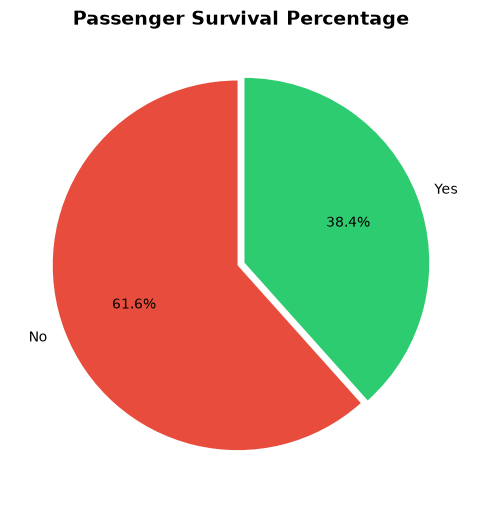

In [130]:
plt.figure(figsize=(6, 6))
##sets the chart size to 6 × 6
colors = ['#e74c3c', '#2ecc71']
##Defines two colors for the pie slices
plt.pie(
    survival_percent,
    labels=survival_percent.index,
    autopct='%1.1f%%',
    colors = colors ,
    startangle=90,
    explode=(0.02, 0.02)
)
##Creates the pie chart
plt.title('Passenger Survival Percentage', fontsize=14, fontweight='bold')
##Adds a bold title with font size 14
plt.show()

**Observation:**  
Only about **38.4%** of passengers survived, while **61.6%** did not survive. This shows that the Titanic disaster was catastrophic, with fewer than 2 in 5 passengers surviving overall.

## Question 2  
Which gender had the highest survival rate? Create a visualization. Explain your findings.

In [131]:
gender_survival = df.groupby('sex')['survived_flag'].mean() * 100
print(gender_survival)

sex
female    74.203822
male      18.890815
Name: survived_flag, dtype: float64


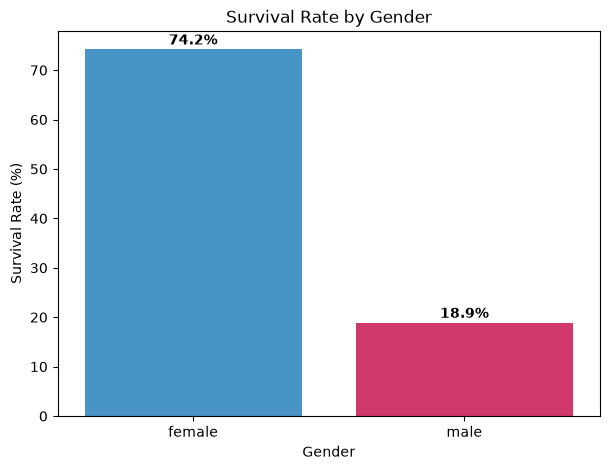

In [124]:
plt.figure(figsize=(7,5))
##Sets the chart size to 7 × 5 inches
ax = sns.barplot(
    x=gender_survival.index,
    y=gender_survival.values,
    hue=gender_survival.index,
    palette=['#3498db','#e91e63'],
    legend=False
)
##Creates the bar chart
plt.title('Survival Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate (%)')
##Adds the title and axis labels
for i, v in enumerate(gender_survival.values):
    ax.text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')
##Writes the exact survival percentage above each bar

**Findings:**  
Female passengers had a much higher survival rate (74.2%) than male passengers (18.9%). This large difference suggests that women were given higher priority during the evacuation, supporting the historical “women and children first” protocol used during the disaster.

### Question 3
Which passenger class had the highest survival rate? Support your answer with a chart.

In [120]:
class_survival = df.groupby('passenger_class')['survived_flag'].mean() * 100
print(class_survival)

passenger_class
1    62.962963
2    47.282609
3    24.236253
Name: survived_flag, dtype: float64


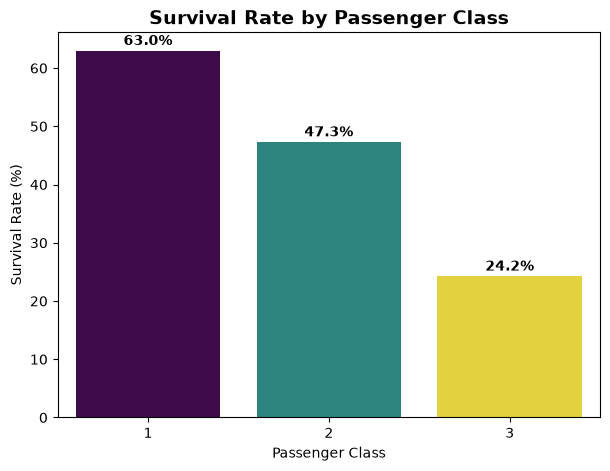

In [132]:
plt.figure(figsize=(7,5))
##Sets the chart size to 7 × 5
ax = sns.barplot(
    x=class_survival.index,
    y=class_survival.values,
    hue=class_survival.index,
    palette='viridis',
    legend=False
)
##Creates the bars
plt.title('Survival Rate by Passenger Class', fontsize=14, fontweight='bold')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate (%)')
##Adds the title and axis labels
for i, v in enumerate(class_survival.values):
    ax.text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')
##Displays the exact survival percentage above each bar
plt.show()

**Findings:**  
First-class passengers had the highest survival rate (63.0%), followed by second-class passengers (47.3%), while third-class passengers had the lowest survival rate (24.2%). This suggests that passenger class was strongly associated with survival, possibly due to differences in access to lifeboats and proximity to upper decks.

### Question 4
Does age affect survival? Use an appropriate visualization. Explain your conclusion.

In [117]:
age_group_survival = df.groupby('age_group', observed=True)['survived_flag'].mean() * 100
print(age_group_survival)

age_group
Child             57.971014
Teenager          41.052632
Adult             36.519258
Senior Citizen    26.923077
Name: survived_flag, dtype: float64


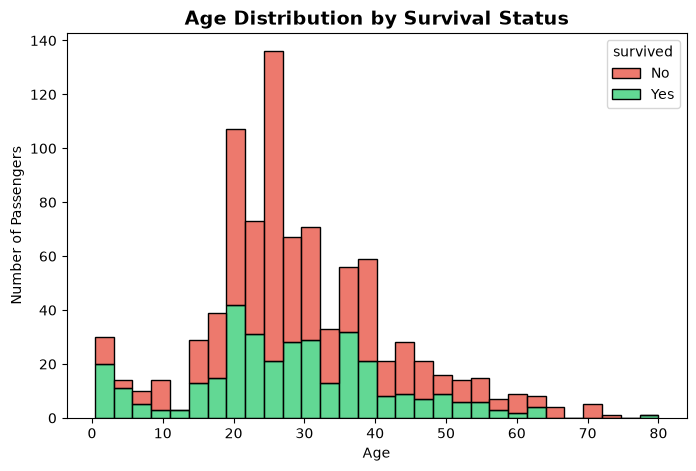

In [133]:
plt.figure(figsize=(8,5))
##Sets the chart size to 8 × 5
sns.histplot(
    data=df,
    x='age',
    hue='survived',
    multiple='stack',
    bins=30,
    palette=['#e74c3c','#2ecc71']
)
#Creates the stacked histogram
plt.title('Age Distribution by Survival Status', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
##Adds the title and axis labels
plt.show()

**Conclusion:**  
Younger passengers generally had better survival chances. Children under 13 had the highest survival rate (58.0%), while senior citizens had the lowest (26.9%). This suggests that children were more likely to be prioritized during evacuation, while older passengers may have faced greater physical difficulty reaching lifeboats.

## Question 5
Does fare influence survival? Support your answer with visualization

In [140]:
print(df.groupby('survived')['fare'].mean())

survived
No     22.118124
Yes    48.395439
Name: fare, dtype: float64


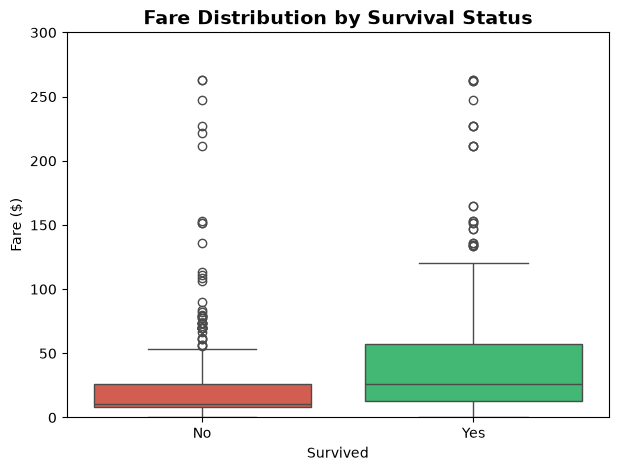

In [141]:
plt.figure(figsize=(7,5))
#Sets the chart size to 7 × 5
sns.boxplot(data=df, x='survived', y='fare',
           hue='survived', palette=['#e74c3c','#2ecc71'],
           legend=False)
#Creates a boxplot comparing ticket fares for passengers who survived and did not survive
plt.title('Fare Distribution by Survival Status', fontsize=14, fontweight='bold')
#Adds a bold title with fontsize 14
plt.xlabel('Survived')
plt.ylabel('Fare ($)')
#Labels the x-axis & y-axis
plt.ylim(0, 300)
#Limits the y-axis to fares between $0 and $300, making the boxplot easier to read
plt.show()


**Observation:**  
Passengers who paid higher fares generally had higher survival rates than those who paid lower fares. Since higher fares were strongly associated with first-class tickets, this suggests that wealthier passengers had a survival advantage, possibly due to better cabin locations and greater access to lifeboats.

### Question 6
Did passengers travelling alone survive more often? Use a visualization. Explain your observation.

In [145]:
alone_survival = df.groupby('Is_alone')['survived_flag'].mean() * 100
print(alone_survival)

Is_alone
No     50.564972
Yes    30.353818
Name: survived_flag, dtype: float64


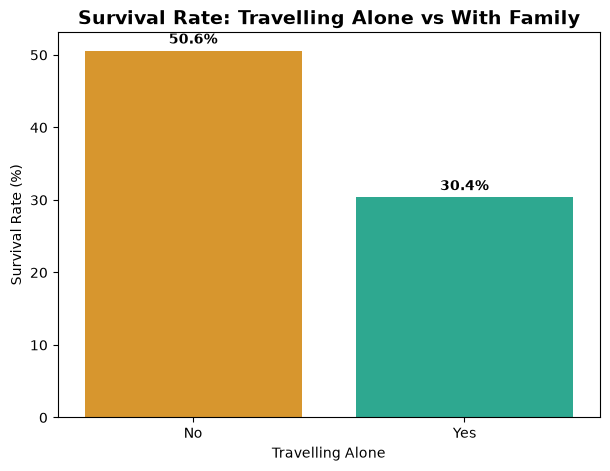

In [146]:
plt.figure(figsize=(7,5))
#Sets the chart size to 7 × 5
ax = sns.barplot(
    x=alone_survival.index,
    y=alone_survival.values,
    hue=alone_survival.index,
    palette=['#f39c12','#1abc9c'],
    legend=False
)
#Creates a bar chart comparing survival rates
plt.title('Survival Rate: Travelling Alone vs With Family',
          fontsize=14, fontweight='bold')
#Adds a bold title with font size 14
plt.xlabel('Travelling Alone')
plt.ylabel('Survival Rate (%)')
##Labels the x-axis & y-axis
for i, v in enumerate(alone_survival.values):
    #Goes through each survival-rate value so we can add its percentage to the chart
    ax.text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')
    #Displays the exact survival percentage above each bar
plt.show()

**Observation:**  
Passengers travelling with family had a higher survival rate (50.6%) than those travelling alone (30.4%). This suggests that travelling with family may have provided support during evacuation, while solo travelers had comparatively lower chances of survival.

### Question 7
Which embarkation port had the highest survival rate? Create a chart and explain the result.

In [148]:
embark_survival = df.groupby('port_of_embarkation')['survived_flag'].mean().sort_values(ascending=False) * 100
print(embark_survival)

port_of_embarkation
Cherbourg      55.357143
Queenstown     38.961039
Southampton    33.900929
Name: survived_flag, dtype: float64


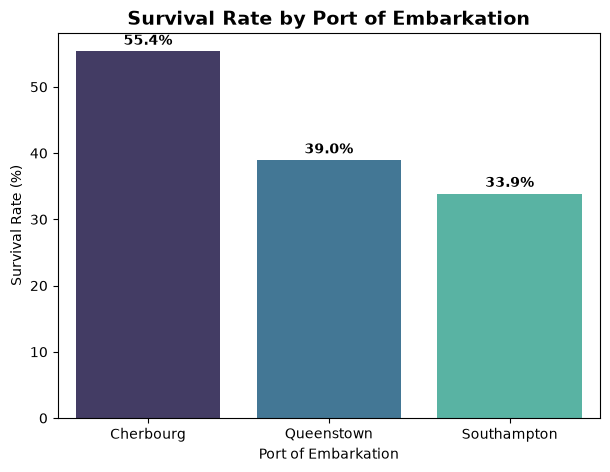

In [149]:
plt.figure(figsize=(7,5))
#Sets the chart size to 7 × 5
ax = sns.barplot(
    x=embark_survival.index,
    y=embark_survival.values,
    hue=embark_survival.index,
    palette='mako',
    legend=False
)
#Creates a bar chart showing survival rates by port of embarkation
plt.title('Survival Rate by Port of Embarkation',
          fontsize=14, fontweight='bold')
#Adds a bold title with font size 14          
plt.xlabel('Port of Embarkation')
plt.ylabel('Survival Rate (%)')
##Labels the x-axis & y-axis
for i, v in enumerate(embark_survival.values):
    #Goes through each survival-rate value so the percentage can be displayed above its bar
    ax.text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')
    #Displays the exact survival percentage above each bar.
plt.show()

**Observation:**  
Passengers boarding at Cherbourg (C) had the highest survival rate (55.4%), followed by Queenstown (39.0%), while Southampton (33.9%) had the lowest. This difference may be partly explained by Cherbourg having a higher proportion of first-class passengers, who generally had higher survival rates.

### Question 8
What is the relationship between passenger class and fare? Support your answer using an appropriate 
visualization

In [150]:
print(df.groupby('passenger_class')['fare'].mean())

passenger_class
1    84.154630
2    20.662174
3    13.675866
Name: fare, dtype: float64


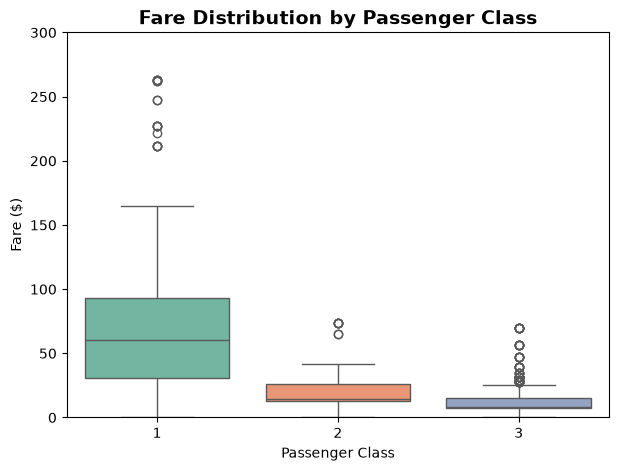

In [151]:
plt.figure(figsize=(7,5))
#Sets the chart size to 7 × 5
sns.boxplot(
    data=df,
    x='passenger_class',
    y='fare',
    hue='passenger_class',
    palette='Set2',
    legend=False
)
#Creates a boxplot comparing ticket fares across passenger classes
plt.title('Fare Distribution by Passenger Class', 
            fontsize=14, fontweight='bold')
#Adds a bold title with font size 14
plt.xlabel('Passenger Class')
plt.ylabel('Fare ($)')
##Labels the x-axis & y-axis
plt.ylim(0, 300)
#Limits the y-axis to fares between $0 and $300, making the main distributions easier to see
plt.show()

**Observation:**  
First-class passengers paid significantly higher fares (approximately $84 on average) than second-class passengers (around $21) and third-class passengers (around $14). This confirms a clear relationship between passenger class and ticket price, with fare and class both serving as indicators of socio-economic status.

### Question 9
Create a Correlation Heatmap. Explain: strongest positive correlation, strongest negative correlation, and any 
interesting observations.

In [172]:
num_cols = ['survived_flag', 'passenger_class', 'age', 'fare', 'siblings_spouses_aboard',
            'parents_children_aboard', 'Family_Size', 'has_cabin_recorded']
corr = df[num_cols].corr()
#create a correlation matrix for the numerical columns in the DataFrame

print(corr['survived_flag'].sort_values(ascending=False))
#Prints the correlation values of all numerical features with respect to the 'survived_flag' column, sorted in descending order

survived_flag              1.000000
has_cabin_recorded         0.316912
fare                       0.257305
parents_children_aboard    0.081629
Family_Size                0.016639
siblings_spouses_aboard   -0.035322
age                       -0.059576
passenger_class           -0.338481
Name: survived_flag, dtype: float64


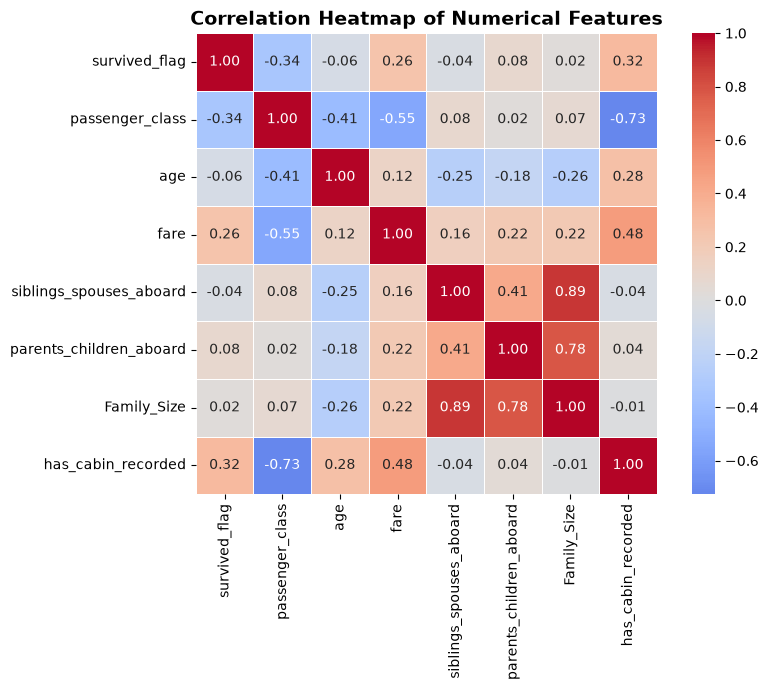

In [173]:
plt.figure(figsize=(9,7))
#Sets a chart size of 9 × 7 inches
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
#Creates a heatmap to visualize the correlation matrix
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
#Adds a bold title with font size 14
plt.tight_layout()
#Ensures that the layout is adjusted to fit all elements within the figure area
plt.show()

**Explanation:** 
- **Strongest positive correlation with survival:** `has_cabin_recorded` (0.32), followed by `fare` (0.26) —
  passengers with a recorded cabin (typically higher classes) and those who paid more were more likely to survive.
- **Strongest negative correlation with survival:** `passenger_class` (-0.34) — since class is coded 1 (best) to 3
  (worst), this negative correlation confirms that a *higher class number* (i.e., a lower-tier ticket) is
  associated with lower survival.
- **Interesting observation:** `siblings_spouses_aboard` and `parents_children_aboard` are strongly correlated
  with each other (0.9), which makes sense since both feed into `family_size`. Age has a very weak negative
  correlation with survival overall, suggesting age alone is a weaker predictor than class or fare.

### Question 10
Create one additional analysis of your own (e.g. Family Size vs Survival, Age Group vs Passenger Class, Fare 
Category vs Survival, Family Size vs Fare, Age Group vs Gender). Explain your findings

In [174]:
family_survival = df.groupby('Family_Size')['survived_flag'].mean() * 100
print(family_survival)

Family_Size
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: survived_flag, dtype: float64


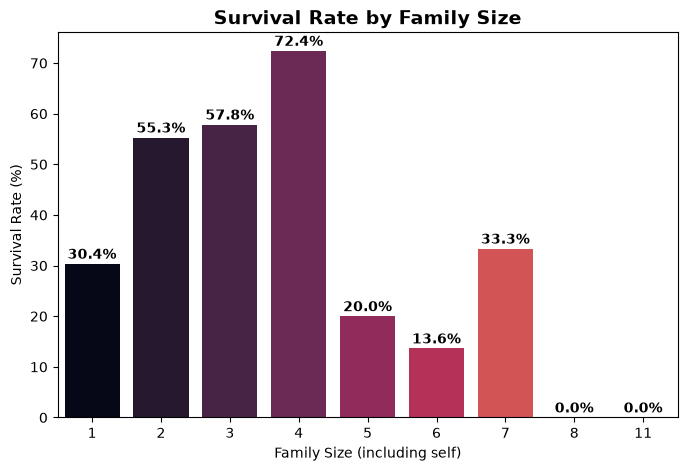

In [176]:
plt.figure(figsize=(8,5))
#Sets the chart size to 8 × 5
ax = sns.barplot(
                x=family_survival.index, 
                y=family_survival.values,
                hue=family_survival.index, 
                palette='rocket', 
                legend=False
)
#Creates a bar chart showing survival rates by family size
plt.title('Survival Rate by Family Size', fontsize=14, fontweight='bold')
#Adds a bold title with font size 14
plt.xlabel('Family Size (including self)')
plt.ylabel('Survival Rate (%)')
#Labels the x-axis & y-axis
for i, v in enumerate(family_survival.values):
    #Goes through each survival-rate value so the percentage can be displayed above its bar
    ax.text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')
    #Displays the exact survival percentage above each bar.
plt.show()

**Findings:**  
Survival rate does **not increase linearly with family size**. Passengers traveling in small
groups (family size 2–4) had noticeably higher survival rates than solo travelers, but very large families
(size 7+) had sharply lower survival rates — likely because large families struggled to stay together and reach
lifeboats in time, or were more concentrated in third class. This suggests a "sweet spot": small family groups
had an advantage, but very large families were a disadvantage.

## Part 4: Statistical Analysis

In [153]:
df.head()

,passenger_id,name,sex,age,passenger_class,ticket_number,fare,deck,has_cabin_recorded,siblings_spouses_aboard,parents_children_aboard,port_of_embarkation,survived,Family_Size,Is_alone,age_group,fare_category,survived_flag
0,1,"Braund, Mr. Owen Harris",male,22.0,3,A/5 21171,7.25,Unknown,0,1,0,Southampton,No,2,No,Adult,Low Fare,0
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,PC 17599,71.28,C,1,1,0,Cherbourg,Yes,2,No,Adult,High Fare,1
2,3,"Heikkinen, Miss. Laina",female,26.0,3,STON/O2. 3101282,7.92,Unknown,0,0,0,Southampton,Yes,1,Yes,Adult,Low Fare,1
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,113803,53.10,C,1,1,0,Southampton,Yes,2,No,Adult,High Fare,1
4,5,"Allen, Mr. William Henry",male,35.0,3,373450,8.05,Unknown,0,0,0,Southampton,No,1,Yes,Adult,Low Fare,0


In [160]:
##Chosen three columns(age, fare, family_size) for statistical analysis
##1. Age
print('Mean_age:', df['age'].mean())
print('Median_age:', df['age'].median())
print('Mode_age:', df['age'].mode()[0])
print('Standard Deviation_age:', df['age'].std())


Mean_age: 29.112457912457913
Median_age: 26.0
Mode_age: 25.0
Standard Deviation_age: 13.304352237003512


In [161]:
#Using For loop for statistical analysis of age, fare and family_size
for column in ['age', 'fare', 'Family_Size']:
    print('mean of', column, ':', df[column].mean())
    print('median of', column, ':', df[column].median())
    print('mode of', column, ':', df[column].mode()[0])
    print('standard deviation of', column, ':', df[column].std())


mean of age : 29.112457912457913
median of age : 26.0
mode of age : 25.0
standard deviation of age : 13.304352237003512
mean of fare : 32.20436588103255
median of fare : 14.45
mode of fare : 8.05
standard deviation of fare : 49.693413676540466
mean of Family_Size : 1.904601571268238
median of Family_Size : 1.0
mode of Family_Size : 1
standard deviation of Family_Size : 1.6134585413550873


In [167]:
#we can also format it using dictionary
stats = {}
for column in ['age', 'fare', 'Family_Size']:
    stats[column] = {
        'mean': df[column].mean().round(2),
        'median': df[column].median(),
        'mode': df[column].mode()[0], #we'll take the first mode value in case of multiple modes
        'std_dev': df[column].std().round(2)
    }
#print(stats)

#we've to convert the dictionary into a DataFrame for better visualization
stats_df = pd.DataFrame(stats).T
stats_df

,mean,median,mode,std_dev
age,29.11,26.00,25.00,13.30
fare,32.20,14.45,8.05,49.69
Family_Size,1.90,1.00,1.00,1.61


**Age:** Mean age (~29.1) is higher than the median (26.0), showing a slight right skew — a small number of
older passengers pull the average up. The mode (25) shows that young adults were the most common age group
aboard. A standard deviation of ~13.3 indicates a fairly wide age spread.

**Fare:** The mean fare (~$32.2) is much higher than the median (~$14.5), indicating strong right skew — a small
number of very expensive first-class tickets inflate the average, while most passengers paid modest fares. The
high standard deviation (~$49.7) confirms this large spread, driven by luxury fares.

**Family Size:** Most passengers traveled with a family size of 1 (i.e., alone) — both the median and mode equal
1. The mean (1.9) being above the median again indicates right skew, caused by a handful of very large families.
The standard deviation (~1.6) shows most passengers had small family groups, with a few outliers of large
families.

## Part 5: Dashboard
A summary dashboard containing the six most important visualizations: Survival Distribution, Gender Distribution,
Passenger Class Distribution, Age Distribution, Fare Distribution, and the Correlation Heatmap.

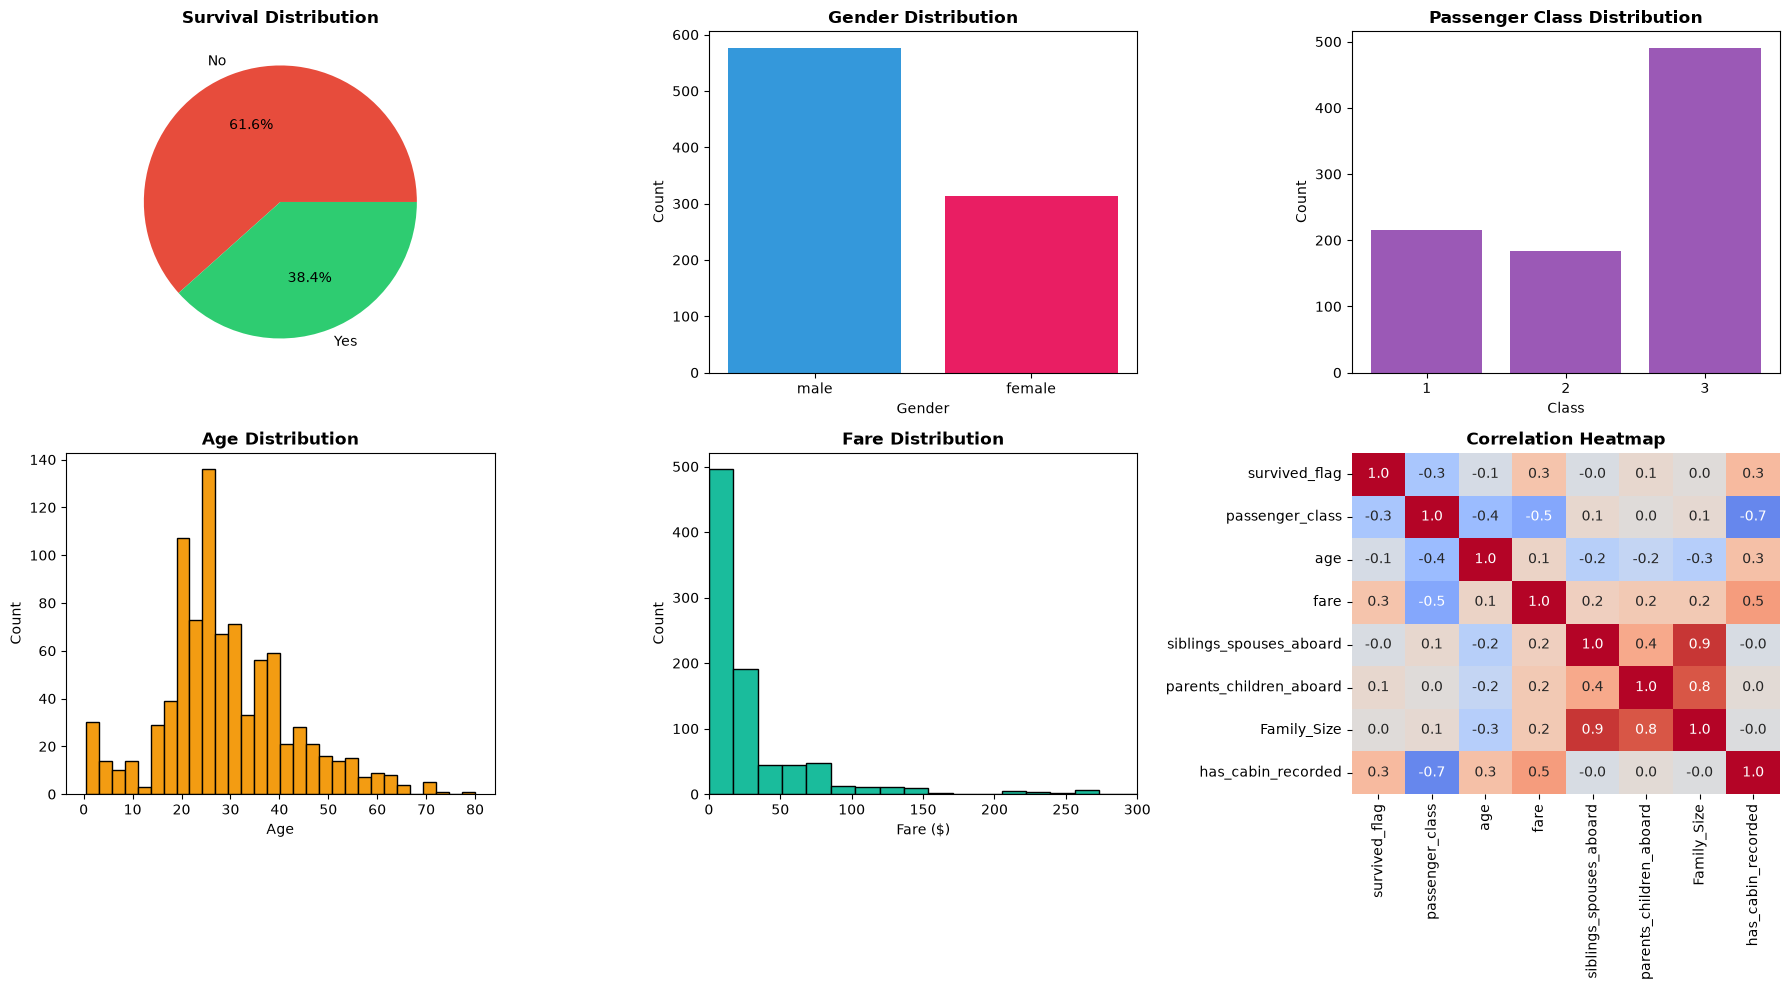

In [178]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
#Creates 2 rows and 3 columns, giving you 6 chart areas

### Survival distribution
axes[0,0].pie(df['survived'].value_counts(), labels=df['survived'].value_counts().index,
              autopct='%1.1f%%', colors=['#e74c3c','#2ecc71'])
#Creates a pie chart showing the percentage of passengers who survived vs. did not survive
axes[0,0].set_title('Survival Distribution', fontweight='bold')

### Gender distribution
sex_counts = df['sex'].value_counts()
#Counts the number of male and female passengers
axes[0,1].bar(sex_counts.index, sex_counts.values, color=['#3498db','#e91e63'])
#Creates a bar chart showing the number of male and female passengers
axes[0,1].set_title('Gender Distribution', fontweight='bold')
axes[0,1].set_xlabel('Gender'); axes[0,1].set_ylabel('Count')

### Class distribution
class_counts = df['passenger_class'].value_counts().sort_index()
#Counts passengers in each class and sorts them in order
axes[0,2].bar(class_counts.index.astype(str), class_counts.values, color='#9b59b6')
#reates a bar chart showing the number of passengers in 1st, 2nd, and 3rd class
axes[0,2].set_title('Passenger Class Distribution', fontweight='bold')
axes[0,2].set_xlabel('Class'); axes[0,2].set_ylabel('Count')

### Age distribution
axes[1,0].hist(df['age'], bins=30, color='#f39c12', edgecolor='black')
#Creates a histogram showing how passenger ages are distributed
axes[1,0].set_title('Age Distribution', fontweight='bold')
axes[1,0].set_xlabel('Age'); axes[1,0].set_ylabel('Count')

### Fare distribution
axes[1,1].hist(df['fare'], bins=30, color='#1abc9c', edgecolor='black')
#Creates a histogram showing the distribution of ticket fares
axes[1,1].set_title('Fare Distribution', fontweight='bold')
axes[1,1].set_xlabel('Fare ($)'); axes[1,1].set_ylabel('Count')
axes[1,1].set_xlim(0, 300)

### Correlation heatmap (mini)
sns.heatmap(corr, annot=True, fmt='.1f', cmap='coolwarm', center=0, ax=axes[1,2], cbar=False)
#Creates a correlation heatmap in the last chart area
axes[1,2].set_title('Correlation Heatmap', fontweight='bold')

plt.tight_layout()
#Automatically adjusts spacing between the six charts so they don't overlap
plt.show()
#Displays the complete 2 × 3 dashboard

## Part 6: Business Insights

Based on the analysis above, here are 10 meaningful insights:

1. **Overall Survival Rate:** Only **38.4% of passengers survived**, while 61.6% did not, showing how severe the Titanic disaster was.

2. **Gender Differences:** **Female passengers had a much higher survival rate (74.2%)** than male passengers (18.9%). This suggests that women were given higher priority during the evacuation.

3. **Passenger Class Impact:** **First-class passengers had the highest survival rate (63.0%)**, while third-class passengers had the lowest (24.2%). This shows that passenger class had a strong effect on survival.

4. **Age and Survival:** **Children under 13 had the highest survival rate (58.0%)**, while senior citizens had the lowest (26.9%). This suggests that younger passengers were given more priority during evacuation.

5. **Fare Influence:** Passengers who paid **higher fares generally had better survival chances**. This is mainly because higher fares were associated with first-class travel.

6. **Family Size:** Passengers travelling with **small families generally had better survival rates** than those travelling alone or with very large families. Families of 7 or more had noticeably lower survival rates.

7. **Traveling Alone:** Passengers travelling **alone had a lower survival rate (30.4%)** compared with those travelling with family (50.6%). Family members may have helped each other during the evacuation.

8. **Embarkation Port:** Survival rates differed by embarkation port. **Cherbourg had the highest survival rate (55.4%)**, followed by Queenstown (39.0%) and Southampton (33.9%). This difference may be related to the class distribution of passengers at each port.

9. **Relationship Between Class and Fare:** There was a clear relationship between passenger class and fare. **First-class passengers paid the highest fares (around $84 on average)**, while third-class passengers paid the lowest (around $14), showing that fare was closely related to socio-economic status.

10. **Correlation Analysis:** The correlation analysis showed that **no single factor completely determined survival**. Survival was influenced by several factors together, including **gender, passenger class, age, fare, and family size**.

## Part 7: Business Recommendations

Presenting to the shipping company's management, based on the evidence above:

1. **Standardize lifeboat access across all classes.** Since third-class passengers survived at less than half the rate of first-class passengers, ensure lifeboat drills and access routes are equally available regardless of ticket class or cabin deck.

2. **Prioritize family-friendly evacuation protocols.** Since children had the highest survival rate but very large families had the lowest, design evacuation procedures that keep family units together and give trained staff responsibility for large families and elderly passengers.

3. **Improve safety provisions for lower-fare passengers.** The clear fare-survival gap suggests structural issues (cabin location, lifeboat proximity) — invest in evacuation infrastructure serving lower-deck and lower-fare passenger areas.

4. **Provide additional assistance for elderly passengers.** With senior citizens showing the lowest survival rate of any age group, create dedicated mobility assistance and priority evacuation support for older travelers.

5. **Conduct mandatory safety briefings at boarding, tailored by embarkation port and class mix.** Since survival outcomes varied meaningfully by port (likely tied to class distribution), ensure every boarding point delivers the same standard of safety briefing and lifeboat assignment regardless of the typical passenger mix that port serves.

## Bonus Challenges (Extra Credit)
### Bonus 1: Logistic Regression — Predicting Survival

We build a Logistic Regression model to predict whether a passenger survived, using passenger class, sex, age,
fare, family size, is-alone status, and port of embarkation as predictors.

In [186]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

# Encode categorical variables
model_data = df.copy()
le_sex = LabelEncoder()
model_data['sex_enc'] = le_sex.fit_transform(model_data['sex'])
le_emb = LabelEncoder()
model_data['embarked_enc'] = le_emb.fit_transform(model_data['port_of_embarkation'])
model_data['Is_alone_enc'] = (model_data['Is_alone'] == 'Yes').astype(int)

#Select features
features = ['passenger_class', 'sex_enc', 'age', 'fare', 'Family_Size', 'Is_alone_enc', 'embarked_enc']

#reate X and y
X = model_data[features]
y = model_data['survived_flag']

#Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create Logistic Regression model
log_model = LogisticRegression(max_iter=1000)

#Train the model
log_model.fit(X_train, y_train)

#Make predictions
y_pred = log_model.predict(X_test)

#Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, log_model.predict_proba(X_test)[:, 1])

print(f"Accuracy: {accuracy:.4f}")
print(f"AUC Score: {auc:.4f}")
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.8045
AUC Score: 0.8522

              precision    recall  f1-score   support

           0       0.82      0.87      0.85       110
           1       0.77      0.70      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



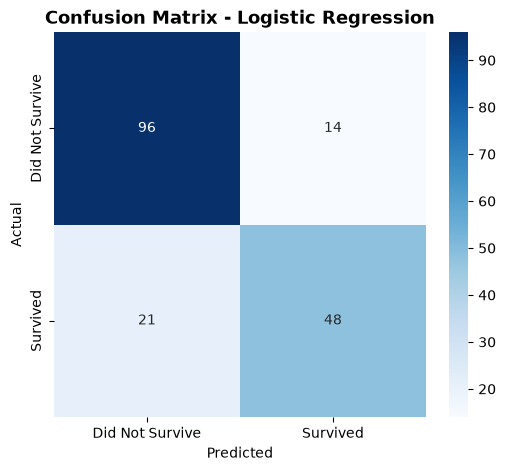

In [187]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Did Not Survive','Survived'],
    yticklabels=['Did Not Survive','Survived']
)
#Creates a heatmap to visualize the confusion matrix
plt.title(
    'Confusion Matrix - Logistic Regression',
    fontsize=13,
    fontweight='bold'
)
#Adds a bold title
plt.xlabel('Predicted'); plt.ylabel('Actual')
#Labels the x-axis & y-axis
plt.show()

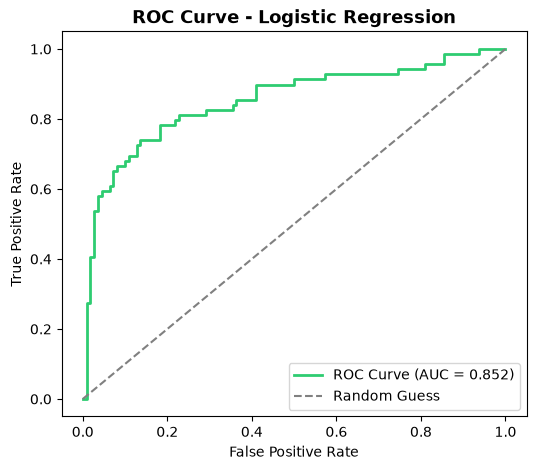

In [188]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, log_model.predict_proba(X_test)[:, 1])
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='#2ecc71', linewidth=2, label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0,1],[0,1], linestyle='--', color='gray', label='Random Guess')
plt.title('ROC Curve - Logistic Regression', fontsize=13, fontweight='bold')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

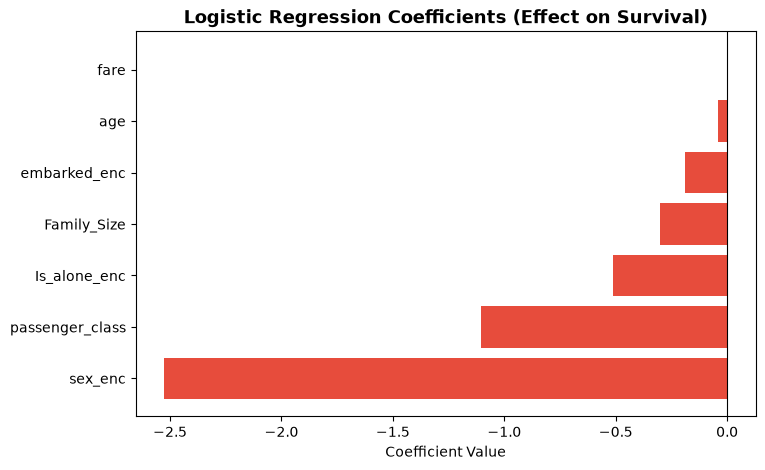

,Feature,Coefficient
3,fare,0.001876
2,age,-0.041194
6,embarked_enc,-0.187041
4,Family_Size,-0.300906
5,Is_alone_enc,-0.513701
0,passenger_class,-1.102571
1,sex_enc,-2.527448


In [191]:
# Feature coefficients (impact on survival)
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': log_model.coef_[0]})
coef_df = coef_df.sort_values('Coefficient')

plt.figure(figsize=(8,5))
colors_bar = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors_bar)
plt.title('Logistic Regression Coefficients (Effect on Survival)', fontsize=13, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

coef_df.sort_values('Coefficient', ascending=False)

**Results & Explanation:**

The model achieved **80.4% accuracy** and an **AUC of 0.85** on the held-out test set, meaning it distinguishes
survivors from non-survivors quite well using just these 7 features.

- **Sex** has the largest effect by far (coefficient -2.53 for male, since female=0/male=1) — being male sharply
  reduced the predicted probability of survival, matching our earlier finding that women survived at much higher
  rates.
- **Passenger class** has the second largest effect (-1.10) — moving to a higher class number (lower-tier ticket)
  reduced survival odds, consistent with our EDA.
- **Is Alone** and **family size** both have negative coefficients, meaning traveling alone or in a larger group
  reduced predicted survival odds relative to small family groups — matching the "sweet spot" pattern found in
  Question 10.
- **Age** has a small negative effect, and **fare** has a small positive effect, both consistent with earlier
  findings but weaker in magnitude once class and sex are already accounted for.

This confirms statistically what the exploratory charts suggested visually: **gender and class were the dominant
drivers of survival**, with family structure playing a secondary role.